# Introduction to vector databases on S&P 500 news

 # 📌 Objectives

 By the end of this notebook, students will be able to:

 1. **Load and Explore Financial News Data:**
    - Load a preprocessed dataset of financial news headlines and summaries related to S&P 500 companies.
    - Inspect and structure relevant metadata including publication date, ticker, and provider.

 2. **Build a Custom Vector Store:**
    - Combine title and summary text for embedding.
    - Implement a vector store from scratch with support for semantic search and optional metadata-based filtering using cosine similarity.

 3. **Generate and Use Sentence Embeddings:**
    - Apply a pre-trained transformer model (all-MiniLM-L6-v2) to encode text into embeddings for semantic analysis.

 4. **Perform Semantic Search with Filtering:**
    - Retrieve the most relevant news documents for a given query using both full-dataset and metadata-filtered searches.

 5. **Analyze Semantic Search Results:**
    - Interpret and visualize results of search queries (e.g., "AI announcement").
    - Identify temporal patterns and ticker frequency among top-ranked results.

 6. **Implement a FAISS-Based Vector Store:**
    - Normalize embeddings and use FAISS (IndexFlatIP) to enable efficient similarity search at scale.
    - Compare FAISS-based search results with custom vector store results.

 7. **Critically Compare Search Systems:**
    - Evaluate differences in similarity computation, speed, and scalability between custom and FAISS-based systems.
    - Reflect on design trade-offs for real-world vector search systems.

## Install and Import important librairies

In [1]:
%pip install sentence-transformers
%pip install faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 84.0 MB/s eta 0:00:00


In [2]:
from sentence_transformers import SentenceTransformer
import faiss
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from collections import Counter
import matplotlib.pyplot as plt
import faiss

## Load news data

Load the provided news dataset and inspect the contents.

 👉 **Instructions**:
 - Load the CSV file named df_news.csv into a pandas DataFrame.
 - Convert the PUBLICATION_DATE column to a proper date format (not datetime).
 - Display the first few rows to understand the data structure. The key columns you’ll be using are:
   - TITLE
   - SUMMARY
   - TICKER
   - PROVIDER
   - PUBLICATION_DATE


In [4]:
df_news = pd.read_csv('df_news.csv')
df_news['PUBLICATION_DATE'] = pd.to_datetime(df_news['PUBLICATION_DATE']).dt.date
display(df_news)

,TICKER,TITLE,SUMMARY,PUBLICATION_DATE,PROVIDER,URL
0,MMM,2 Dow Jones Stocks with Promising Prospects an...,The Dow Jones (^DJI) is made up of 30 of the m...,2025-05-29,StockStory,https://finance.yahoo.com/news/2-dow-jones-sto...
1,MMM,3 S&P 500 Stocks Skating on Thin Ice,The S&P 500 (^GSPC) is often seen as a benchma...,2025-05-27,StockStory,https://finance.yahoo.com/news/3-p-500-stocks-...
2,MMM,3M Rises 15.8% YTD: Should You Buy the Stock N...,"MMM is making strides in the aerospace, indust...",2025-05-22,Zacks,https://finance.yahoo.com/news/3m-rises-15-8-y...
3,MMM,Q1 Earnings Roundup: 3M (NYSE:MMM) And The Res...,Quarterly earnings results are a good time to ...,2025-05-22,StockStory,https://finance.yahoo.com/news/q1-earnings-rou...
4,MMM,3 Cash-Producing Stocks with Questionable Fund...,While strong cash flow is a key indicator of s...,2025-05-19,StockStory,https://finance.yahoo.com/news/3-cash-producin...
...,...,...,...,...,...,...
4866,ZTS,2 Dividend Stocks to Buy With $500 and Hold Fo...,Zoetis is a leading animal health company with...,2025-05-23,Motley Fool,https://www.fool.com/investing/2025/05/23/2-di...
4867,ZTS,Zoetis (NYSE:ZTS) Declares US$0.50 Dividend Pe...,Zoetis (NYSE:ZTS) recently affirmed a dividend...,2025-05-22,Simply Wall St.,https://finance.yahoo.com/news/zoetis-nyse-zts...
4868,ZTS,Jim Cramer on Zoetis (ZTS): “It Does Seem to B...,We recently published a list of Jim Cramer Tal...,2025-05-21,Insider Monkey,https://finance.yahoo.com/news/jim-cramer-zoet...
4869,ZTS,Zoetis (ZTS) Upgraded to Buy: Here's Why,Zoetis (ZTS) might move higher on growing opti...,2025-05-21,Zacks,https://finance.yahoo.com/news/zoetis-zts-upgr...


## Implement custom vector store

You will now implement a basic vector store from scratch. This class will allow you to:
1. Store embedded text and metadata.
2. Perform filtered semantic search using cosine similarity.

 👉 **Instructions**:

### Step 1: Prepare Documents
 - Combine the TITLE and SUMMARY columns into a single column named EMBEDDED_TEXT.
 - This combined text will be embedded later.

### Step 2: Load Embedding Model
 - Load the 'all-MiniLM-L6-v2' model from sentence-transformers.

### Step 3: Define CustomVectorStore Class
 Implement the class with the following methods (functions):

 - '__init__': Accepts an embedding model, list of documents, and corresponding metadata. Computes and stores embeddings for all documents.
 - search: Takes a query and returns the top k most similar documents, optionally filtered using metadata.
   - If a metadata_filter function is provided, apply it before computing similarity.
   - Use cosine similarity to compute distances.
   - Return the top k results as tuples of: (document, metadata, similarity score).

 ✅ **Requirements**:
 - Ensure the number of documents matches the number of metadata entries.
 - Make use of sklearn.metrics.pairwise.cosine_similarity.

You will test your class at the end.

In [5]:
# Step 1: Combine TITLE and SUMMARY into EMBEDDED_TEXT
df_news['EMBEDDED_TEXT'] = (
    df_news['TITLE'].fillna('') + ' ' + df_news['SUMMARY'].fillna('')
)

# Step 2: Load the embedding model
model = SentenceTransformer('all-MiniLM-L6-v2')


# Step 3: Define the CustomVectorStore class
class CustomVectorStore:
    def __init__(self, embedding_model, documents, metadata):

        # Make sure documents and metadata have the same length
        assert len(documents) == len(metadata), \
            "Documents and metadata must have the same length."

        self.embedding_model = embedding_model
        self.documents = documents
        self.metadata = metadata

        # Generate embeddings for all documents
        self.embeddings = self.embedding_model.encode(
            documents,
            convert_to_numpy=True,
            show_progress_bar=True
        )

    def search(self, query, k=5, metadata_filter=None):

        # Generate embedding for the query
        query_embedding = self.embedding_model.encode(
            [query],
            convert_to_numpy=True
        )

        # Select documents according to metadata filter
        if metadata_filter is not None:
            valid_indices = [
                i for i, meta in enumerate(self.metadata)
                if metadata_filter(meta)
            ]
        else:
            valid_indices = list(range(len(self.documents)))

        # If no documents satisfy the filter
        if len(valid_indices) == 0:
            return []

        # Get embeddings for valid documents
        filtered_embeddings = self.embeddings[valid_indices]

        # Calculate cosine similarities
        similarities = cosine_similarity(
            query_embedding,
            filtered_embeddings
        )[0]

        # Get indices of top k most similar documents
        top_indices = np.argsort(similarities)[::-1][:k]

        # Build results
        results = []

        for idx in top_indices:
            original_idx = valid_indices[idx]

            results.append(
                (
                    self.documents[original_idx],
                    self.metadata[original_idx],
                    similarities[idx]
                )
            )

        return results

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]


## Create and populate the vector store

 👉 **Instructions**:
 - Convert the combined EMBEDDED_TEXT column into a list of strings.
 - Create a metadata list of dictionaries for each document with keys:
   - 'PUBLICATION_DATE'
   - 'TICKER'
   - 'PROVIDER'
 - Instantiate your CustomVectorStore using:
   - The embedding model.
   - The list of document strings.
   - The metadata list.

 After initializing the store, you should be able to perform searches using:
'store.search("Apple earnings", k=3)'


In [6]:
# Convert EMBEDDED_TEXT column into a list of strings
documents = df_news['EMBEDDED_TEXT'].tolist()

# Create metadata list
metadata = df_news[
    ['PUBLICATION_DATE', 'TICKER', 'PROVIDER']
].to_dict(orient='records')

# Instantiate the custom vector store
store = CustomVectorStore(
    embedding_model=model,
    documents=documents,
    metadata=metadata
)

# Test the vector store
results = store.search("Apple earnings", k=3)

# Display results
for document, meta, score in results:
    print("Similarity score:", score)
    print("Metadata:", meta)
    print("Document:", document)
    print("-" * 80)

Batches:   0%|          | 0/153 [00:00<?, ?it/s]

Similarity score: 0.5717154
Metadata: {'PUBLICATION_DATE': datetime.date(2025, 5, 1), 'TICKER': 'APTV', 'PROVIDER': 'Barrons.com'}
Document: Aptiv Stock Rises. Earnings Were Great, But Tariff Impact Is Still Uncertain. Thursday morning, Aptiv reported first-quarter earnings per share of $1.69 from sales of $4.8 billion in sales. Wall Street was looking for EPS of $1.53 from sales of $4.8 billion.
--------------------------------------------------------------------------------
Similarity score: 0.5700959
Metadata: {'PUBLICATION_DATE': datetime.date(2025, 4, 30), 'TICKER': 'OKE', 'PROVIDER': 'Simply Wall St.'}
Document: ONEOK (NYSE:OKE) Reports Q1 2025 Revenue Surge to US$8 Billion ONEOK (NYSE:OKE) recently released its first-quarter earnings, reporting revenue of USD 8,043 million, a marked increase year-over-year, but a minor dip in net income and earnings per share. Alongside this, the company reaffirmed its quarterly dividend of $1.03 per share. These updates coincide with a 4.5% pri

## Using your vector store and analyzing the results

### Retrieve AI Announcements

 Now that your vector store is working, let's use it to retrieve relevant documents.

 👉 **Instructions**:
 - Perform a semantic search using the query `"AI announcement"` with `k=50` to retrieve the top 50 most relevant articles.
 - Display each result's:
   - `TICKER`
   - `PUBLICATION_DATE`
   - `PROVIDER`
   - Similarity score
   - Full document text


In [7]:
# Semantic search for AI announcements
ai_results = store.search("AI announcement", k=50)

# Display the retrieved results
for i, (document, meta, score) in enumerate(ai_results, start=1):
    print(f"Result {i}")
    print(f"TICKER: {meta['TICKER']}")
    print(f"PUBLICATION_DATE: {meta['PUBLICATION_DATE']}")
    print(f"PROVIDER: {meta['PROVIDER']}")
    print(f"Similarity Score: {score:.4f}")
    print(f"Document: {document}")
    print("-" * 100)

Result 1
TICKER: ADBE
PUBLICATION_DATE: 2025-05-27
PROVIDER: Investor's Business Daily
Similarity Score: 0.5567
Document: AI Stocks Face 'Show Me' Moment. Nvidia Earnings Due With China In Focus. Amid hype over artificial intelligence, the best AI stocks generate revenue or get a strategic edge from the fast evolving technology.
----------------------------------------------------------------------------------------------------
Result 2
TICKER: JKHY
PUBLICATION_DATE: 2025-03-17
PROVIDER: Insider Monkey
Similarity Score: 0.5467
Document: Jack Henry (JKHY) Integrates AI-Driven Lending Tech With Algebrik We recently published a list of 12 AI News Investors Should Not Miss This Week. In this article, we are going to take a look at where Jack Henry & Associates, Inc. (NASDAQ:JKHY) stands against other AI news Investors should not miss this week. Artificial Intelligence (AI) is known to increase productivity, decrease human error, […]
---------------------------------------------------------

 ### **Q1.** What are the top companies (by TICKER) most frequently appearing in the top 50 search results for the query "AI announcement"?  
 Check their company names on Yahoo Finance. Are you surprised by the results?

 ✅ **Your task**:
 - Count the number of times each TICKER appears.
 - Print and analyze the top results.

In [8]:
# Count how many times each ticker appears in the top 50 results
ticker_counts = Counter(
    meta['TICKER']
    for document, meta, score in ai_results
)

# Convert counts to a DataFrame
ticker_counts_df = pd.DataFrame(
    ticker_counts.most_common(),
    columns=['TICKER', 'COUNT']
)

# Display results
display(ticker_counts_df)

# Print the top 10 tickers
print("Top 10 most frequent tickers:")
for ticker, count in ticker_counts.most_common(10):
    print(f"{ticker}: {count}")

,TICKER,COUNT
0,PLTR,5
1,BKR,3
2,AMD,3
3,CTSH,3
4,QCOM,2
5,META,2
6,AMZN,2
7,MSFT,2
8,EXPE,2
9,INTC,2


Top 10 most frequent tickers:
PLTR: 5
BKR: 3
AMD: 3
CTSH: 3
QCOM: 2
META: 2
AMZN: 2
MSFT: 2
EXPE: 2
INTC: 2


The most frequent tickers were **PLTR (5)**, **BKR (3)**, **AMD (3)**, and **CTSH (3)**. These correspond to **Palantir Technologies, Baker Hughes, Advanced Micro Devices, and Cognizant Technology Solutions**, respectively.

I am not surprised by Palantir, AMD, and Cognizant because AI is closely related to their businesses. Baker Hughes was more surprising because it is primarily an energy technology company, although it also uses advanced technology and AI-related solutions.


### **Q2.** What is the date range of the top 50 results? Are the articles evenly distributed across time?

 ✅ **Your task**:
 - Extract the publication dates of the top 50 results.
 - Plot a histogram to visualize the temporal distribution.
 - Reflect: Are these mentions clustered in recent months or spread evenly?

 🧠 **Follow-up**: What could explain the timing of increased AI announcements?

Earliest date: 2025-03-17
Latest date: 2025-05-31


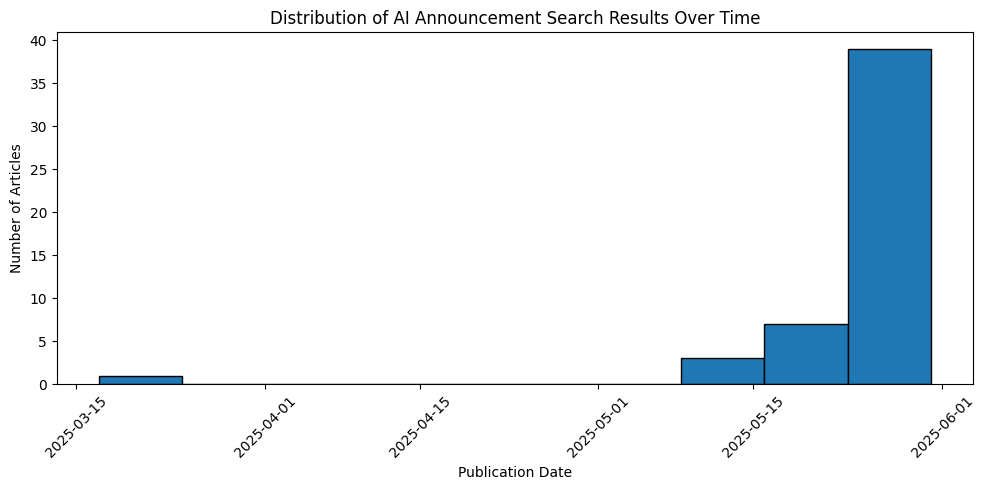

In [9]:
# Extract publication dates from the top 50 results
publication_dates = [
    pd.to_datetime(meta['PUBLICATION_DATE'])
    for document, meta, score in ai_results
]

# Print date range
print("Earliest date:", min(publication_dates).date())
print("Latest date:", max(publication_dates).date())

# Plot histogram
plt.figure(figsize=(10, 5))
plt.hist(publication_dates, bins=10, edgecolor='black')

plt.title('Distribution of AI Announcement Search Results Over Time')
plt.xlabel('Publication Date')
plt.ylabel('Number of Articles')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The top 50 results range from **March 17, 2025 to May 31, 2025**. The articles are not evenly distributed over time; most are strongly concentrated in **May 2025**, especially toward the end of the month.

This clustering may reflect increased AI product launches, investments, earnings-related announcements, and growing competition among companies to introduce new AI capabilities.



## Implement FAISS vector store

 We’ll now implement a **FAISS-based vector store**, designed for efficient similarity search at scale.

 👉 **Steps**:
 - Use the same sentence transformer model: all-MiniLM-L6-v2.
 - Encode your text into embessings
 - Normalize the vectors.

 FAISS supports multiple similarity types. For cosine similarity, we must:

 ✅ Normalize vectors to unit length  
 ✅ Use `IndexFlatIP` (inner product), because:
 - For normalized vectors, inner product = cosine similarity


In [10]:
# Load the same embedding model
faiss_model = SentenceTransformer('all-MiniLM-L6-v2')

# Encode the documents
faiss_embeddings = faiss_model.encode(
    documents,
    convert_to_numpy=True,
    show_progress_bar=True
).astype('float32')

# Normalize embeddings to unit length
faiss.normalize_L2(faiss_embeddings)

# Check the embeddings
print("Embeddings shape:", faiss_embeddings.shape)
print("Norm of first embedding:", np.linalg.norm(faiss_embeddings[0]))

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/153 [00:00<?, ?it/s]

Embeddings shape: (4871, 384)
Norm of first embedding: 1.0


We’ll now:
 - Initialize the FAISS index
 - Add the document embeddings

In [11]:
# Get embedding dimension
dimension = faiss_embeddings.shape[1]

# Initialize FAISS index using inner product
index = faiss.IndexFlatIP(dimension)

# Add normalized document embeddings to the index
index.add(faiss_embeddings)

# Verify
print("FAISS index dimension:", index.d)
print("Number of vectors in index:", index.ntotal)

FAISS index dimension: 384
Number of vectors in index: 4871


### Create a `FaissVectorStore` class with a `.search()` method.

 This method:
 - Encodes and normalizes the query
 - Optionally applies metadata filters
 - Returns top `k` results with similarity scores and metadata

In [16]:
class FaissVectorStore:
    def __init__(self, embedding_model, documents, metadata, embeddings):
        assert len(documents) == len(metadata), \
            "Documents and metadata must have the same length."

        self.embedding_model = embedding_model
        self.documents = documents
        self.metadata = metadata
        self.embeddings = embeddings.astype('float32')

        # Create FAISS index
        dimension = self.embeddings.shape[1]
        self.index = faiss.IndexFlatIP(dimension)
        self.index.add(self.embeddings)

    def search(self, query, k=5, metadata_filter=None):

        # Encode query
        query_embedding = self.embedding_model.encode(
            [query],
            convert_to_numpy=True
        ).astype('float32')

        # Normalize query for cosine similarity
        faiss.normalize_L2(query_embedding)

        # If there is no metadata filter, search directly
        if metadata_filter is None:
            scores, indices = self.index.search(query_embedding, k)

            results = []

            for score, idx in zip(scores[0], indices[0]):
                results.append(
                    (
                        self.documents[idx],
                        self.metadata[idx],
                        float(score)
                    )
                )

            return results

        # Apply metadata filter
        valid_indices = [
            i for i, meta in enumerate(self.metadata)
            if metadata_filter(meta)
        ]

        if len(valid_indices) == 0:
            return []

        # Create temporary FAISS index with filtered embeddings
        filtered_embeddings = self.embeddings[valid_indices]

        filtered_index = faiss.IndexFlatIP(
            filtered_embeddings.shape[1]
        )

        filtered_index.add(filtered_embeddings)

        # Search only among filtered documents
        search_k = min(k, len(valid_indices))

        scores, indices = filtered_index.search(
            query_embedding,
            search_k
        )

        results = []

        for score, filtered_idx in zip(scores[0], indices[0]):
            original_idx = valid_indices[filtered_idx]

            results.append(
                (
                    self.documents[original_idx],
                    self.metadata[original_idx],
                    float(score)
                )
            )

        return results








faiss_store = FaissVectorStore(
    embedding_model=faiss_model,
    documents=documents,
    metadata=metadata,
    embeddings=faiss_embeddings
)

 Let’s run a semantic search using FAISS:
 - Query: `"AI announcement"`
 - Top results: `k=50`

 Print out:
 - Ticker
 - Publication date
 - Provider
 - Cosine similarity score
 - Full text

In [17]:
# Run FAISS semantic search
faiss_results = faiss_store.search(
    "AI announcement",
    k=50
)

# Display results
for i, (document, meta, score) in enumerate(faiss_results, start=1):
    print(f"Result {i}")
    print(f"TICKER: {meta['TICKER']}")
    print(f"PUBLICATION_DATE: {meta['PUBLICATION_DATE']}")
    print(f"PROVIDER: {meta['PROVIDER']}")
    print(f"Cosine Similarity: {score:.4f}")
    print(f"Document: {document}")
    print("-" * 100)

Result 1
TICKER: ADBE
PUBLICATION_DATE: 2025-05-27
PROVIDER: Investor's Business Daily
Cosine Similarity: 0.5567
Document: AI Stocks Face 'Show Me' Moment. Nvidia Earnings Due With China In Focus. Amid hype over artificial intelligence, the best AI stocks generate revenue or get a strategic edge from the fast evolving technology.
----------------------------------------------------------------------------------------------------
Result 2
TICKER: JKHY
PUBLICATION_DATE: 2025-03-17
PROVIDER: Insider Monkey
Cosine Similarity: 0.5467
Document: Jack Henry (JKHY) Integrates AI-Driven Lending Tech With Algebrik We recently published a list of 12 AI News Investors Should Not Miss This Week. In this article, we are going to take a look at where Jack Henry & Associates, Inc. (NASDAQ:JKHY) stands against other AI news Investors should not miss this week. Artificial Intelligence (AI) is known to increase productivity, decrease human error, […]
-------------------------------------------------------

## Evaluation: Comparing FAISS Vector Store with your Custom Vector Store

### Retrieval Comparison Across Systems

 👉 **Instructions**:

 - Using the 5 'test_queries' provided in the list below, retrieve the top 5 news for each query using both your custom and FAISS vector stores.
 - Inspect how similar the returned news texts are for each query.
 - Focus especially on the order of results (not just their presence).


In [18]:
test_queries = [
    'Stock price drop',
    'Layoffs',
    'Mergers and acquisitions',
    'Fed interest rate',
    'Regulation',
    'Cryptocurrency'

]

In [19]:
for query in test_queries:

    print("=" * 120)
    print(f"QUERY: {query}")
    print("=" * 120)

    # Search using both vector stores
    custom_results = store.search(query, k=5)
    faiss_results_test = faiss_store.search(query, k=5)

    print("\nCUSTOM VECTOR STORE")
    print("-" * 120)

    for rank, (document, meta, score) in enumerate(custom_results, start=1):
        print(f"Rank {rank}")
        print(f"Ticker: {meta['TICKER']}")
        print(f"Date: {meta['PUBLICATION_DATE']}")
        print(f"Score: {score:.4f}")
        print(f"Document: {document}")
        print()

    print("\nFAISS VECTOR STORE")
    print("-" * 120)

    for rank, (document, meta, score) in enumerate(faiss_results_test, start=1):
        print(f"Rank {rank}")
        print(f"Ticker: {meta['TICKER']}")
        print(f"Date: {meta['PUBLICATION_DATE']}")
        print(f"Score: {score:.4f}")
        print(f"Document: {document}")
        print()

QUERY: Stock price drop

CUSTOM VECTOR STORE
------------------------------------------------------------------------------------------------------------------------
Rank 1
Ticker: PKG
Date: 2025-05-29
Score: 0.5706
Document: 3 Reasons to Avoid PKG and 1 Stock to Buy Instead Packaging Corporation of America has gotten torched over the last six months - since November 2024, its stock price has dropped 21.6% to $195 per share. This might have investors contemplating their next move.

Rank 2
Ticker: HUM
Date: 2025-05-27
Score: 0.5700
Document: 2 Reasons to Like HUM and 1 to Stay Skeptical Humana has gotten torched over the last six months - since November 2024, its stock price has dropped 24.3% to a new 52-week low of $224.50 per share. This may have investors wondering how to approach the situation.

Rank 3
Ticker: CRL
Date: 2025-05-21
Score: 0.5533
Document: Guardant Health, Evolent Health, Charles River Laboratories, Avantor, and Lumen Stocks Trade Down, What You Need To Know A number 

### **Q3.** Do you observe any significant differences in the top-5 retrieved results for each query between the two systems? Explain why these differences may or may not occur.

There were **no significant differences** between the two systems. For almost all queries, the same articles appeared in the same order with the same similarity scores.

The only small difference appeared for **“Mergers and acquisitions”**, where the fifth result had a different ticker (ANSS vs. SNPS), but it was actually the same article and similarity score. This is expected because both systems use the same MiniLM embeddings and cosine similarity. Since FAISS uses normalized vectors with `IndexFlatIP`, its results should be nearly identical to the custom implementation.



## Evaluation: Comparing 2 embedding models with your Custom Vector Store

 👉 **Instructions**:

 - Implement your custom vector store with `'all-MiniLM-L6-v2'` model from `sentence-transformers`, and compare it with the `'all-mpnet-base-v2'` model from `sentence-transformers`.
 - Similarly, retrieve the top 5 news for each query using both implementations.
 - Inspect how similar the returned news texts are for each query.
 - Focus especially on the order of results (not just their presence).

In [20]:
# Load the second embedding model
mpnet_model = SentenceTransformer('all-mpnet-base-v2')

# Create a CustomVectorStore using MPNet
mpnet_store = CustomVectorStore(
    embedding_model=mpnet_model,
    documents=documents,
    metadata=metadata
)

# Compare MiniLM vs MPNet for each test query
for query in test_queries:

    print("=" * 120)
    print(f"QUERY: {query}")
    print("=" * 120)

    # Search with both embedding models
    minilm_results = store.search(query, k=5)
    mpnet_results = mpnet_store.search(query, k=5)

    print("\nMINILM RESULTS")
    print("-" * 120)

    for rank, (document, meta, score) in enumerate(minilm_results, start=1):
        print(f"Rank {rank}")
        print(f"Ticker: {meta['TICKER']}")
        print(f"Date: {meta['PUBLICATION_DATE']}")
        print(f"Score: {score:.4f}")
        print(f"Document: {document}")
        print()

    print("\nMPNET RESULTS")
    print("-" * 120)

    for rank, (document, meta, score) in enumerate(mpnet_results, start=1):
        print(f"Rank {rank}")
        print(f"Ticker: {meta['TICKER']}")
        print(f"Date: {meta['PUBLICATION_DATE']}")
        print(f"Score: {score:.4f}")
        print(f"Document: {document}")
        print()

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/11.6k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/153 [00:00<?, ?it/s]

QUERY: Stock price drop

MINILM RESULTS
------------------------------------------------------------------------------------------------------------------------
Rank 1
Ticker: PKG
Date: 2025-05-29
Score: 0.5706
Document: 3 Reasons to Avoid PKG and 1 Stock to Buy Instead Packaging Corporation of America has gotten torched over the last six months - since November 2024, its stock price has dropped 21.6% to $195 per share. This might have investors contemplating their next move.

Rank 2
Ticker: HUM
Date: 2025-05-27
Score: 0.5700
Document: 2 Reasons to Like HUM and 1 to Stay Skeptical Humana has gotten torched over the last six months - since November 2024, its stock price has dropped 24.3% to a new 52-week low of $224.50 per share. This may have investors wondering how to approach the situation.

Rank 3
Ticker: CRL
Date: 2025-05-21
Score: 0.5533
Document: Guardant Health, Evolent Health, Charles River Laboratories, Avantor, and Lumen Stocks Trade Down, What You Need To Know A number of st

### **Q4.**  Which embedding model performs better in retrieving relevant documents for the queries? Support your answer with specific examples from the results.

Overall, MPNet performs slightly better for broader semantic queries, although MiniLM is better in some cases. For example, for “Stock price drop”, MPNet retrieves articles explicitly about HP, Starbucks, and Uber stocks falling. For “Mergers and acquisitions”, it ranks an article about M&A target stocks first, and for “Cryptocurrency” it retrieves directly related articles about Coinbase, Fifth Third’s crypto plans, and CME crypto products.

However, MiniLM performed better for “Layoffs” and “Fed interest rate”, where its results were more directly related to the exact query. Therefore, MPNet seems better at capturing broader semantic meaning, while MiniLM can be stronger for more literal searches.

## 🛠️ Implementation-Level Questions

### **Q5.**  What role does vector normalization play in each implementation?

Vector normalization makes each embedding have a length of 1, so similarity depends on the direction of the vectors rather than their magnitude. In the custom vector store, cosine_similarity handles this calculation directly. In FAISS, normalization is necessary because IndexFlatIP uses inner product; with normalized vectors, the inner product becomes equivalent to cosine similarity.



### **Q6.**  What would happen if vectors were not normalized before indexing?

If vectors were not normalized, IndexFlatIP would measure the raw dot product instead of cosine similarity. This means vectors with larger magnitudes could receive higher scores even if they are not the most semantically similar, which could distort the ranking.



## 🧠 Critical Thinking / Design Choices


### **Q7.** Which implementation would you choose for a production-scale search system? Why?


For a production-scale system, I would choose FAISS because it is optimized for fast vector similarity search and can handle much larger datasets efficiently. The custom implementation is useful for learning and small datasets, but it becomes slower as the number of documents grows.


### **Q8.**   If your dataset grows from 5K to 5M articles, which implementation will scale better? Justify your answer.

For 5 million articles, FAISS would scale much better. The custom store must compare the query against a large number of vectors using Python/NumPy operations, while FAISS is specifically designed for efficient vector indexing and retrieval. It also supports more advanced indexes that can trade a small amount of accuracy for much faster searches.
